# 30 · Opto — uniform (expert) phase

## Setup

In [1]:
%matplotlib inline
from shared_setup import *
from behav_utils.analysis.downsample import calculate_min_n, compute_ds_x
from behav_utils.analysis.stats_table import extract_stats


experiment, info = load_data()
print(f"Mode: {info['mode']}")

Loaded snapshot: 22 animals, 1267 sessions (exported 2026-07-20)
Mode: snapshot


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:223: UserWarning: Config has changed since snapshot was exported. Re-export if column mappings changed.
  experiment, meta = load_snapshot(


## Per Animal

In [2]:
animal_id = 'SS16'
animal = experiment.get_animal(animal_id)
print(f"Animal: {animal.animal_id} ({animal.genotype.upper()})")

Animal: SS16 (HET)


### Per Phase

#### Select Session & Trials

In [3]:
distribution = 'Uniform'
session_type = 'masking'
phase_unfiltered = select_sessions(animal, distribution=distribution, session_type=session_type)

phases_dist_sessionType = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

#### Compute Stats

##### Stats

In [4]:
stat_names = ['accuracy', 'recency', 'win_stay', 'lose_shift', 'side_bias', 
              'psychometric', 'psychometric_gof',
              'hard_accuracy', 'easy_accuracy']

In [ ]:
stats_full_dist_sessionType = compare_phases(phases_dist_sessionType, stats=stat_names, downsample = False, 
                   n_permutations = 200, n_bootstrap = 200, 
                   reference='non_opto')

In [6]:
stats_ds_dist_sessionType = compare_phases(phases_dist_sessionType, stats=stat_names, downsample = True,
						  n_permutations = 200, n_bootstrap = 200, reference = 'non_opto')

##### Update matrices

Full

In [ ]:
phase_opto_um_dist_sessionType = compute_um(phases_dist_sessionType['opto'])
phase_non_opto_um_dist_sessionType = compute_um(phases_dist_sessionType['non_opto'])
phase_post_opto_um_dist_sessionType = compute_um(phases_dist_sessionType['post_opto'])

Downsampled

In [ ]:
n = calculate_min_n([phases_dist_sessionType['opto'], phases_dist_sessionType['non_opto'], phases_dist_sessionType['post_opto']], unit = 'pairs')
phase_opto_ds_um_full_dist_sessionType = compute_ds_x(phases_dist_sessionType['opto'], 'um', n, n_repeats=100)   # 100 matched draws, aggregated
phase_non_opto_ds_um_full_dist_sessionType = compute_ds_x(phases_dist_sessionType['non_opto'], 'um', n, n_repeats=100)
phase_post_opto_ds_um_full_dist_sessionType = compute_ds_x(phases_dist_sessionType['post_opto'], 'um', n, n_repeats=100)
phase_opto_ds_um_dist_sessionType = phase_opto_ds_um_full_dist_sessionType['aggregated']
phase_non_opto_ds_um_dist_sessionType = phase_non_opto_ds_um_full_dist_sessionType['aggregated']
phase_post_opto_ds_um_dist_sessionType = phase_post_opto_ds_um_full_dist_sessionType['aggregated']

#### Plot Stats

##### Psychometrics

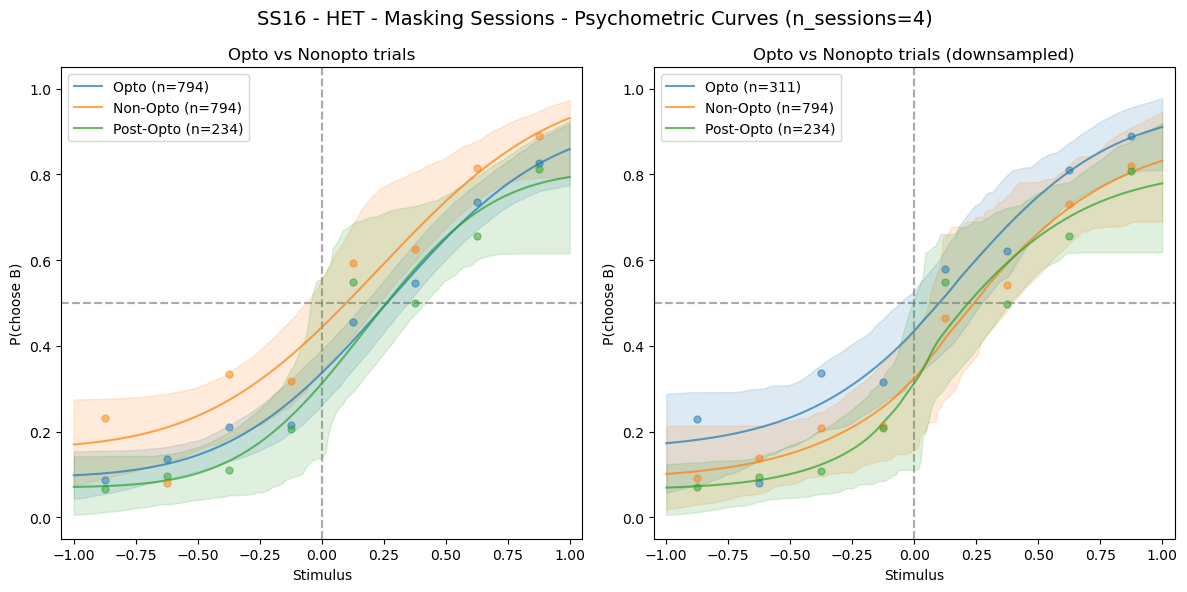

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Full
plot_psychometric(stats_full_dist_sessionType['phases']['non_opto']['psychometric'], title=f"Opto vs Nonopto trials ", ax = axes[0], color = PALETTE[0], 
                  label=f'Opto (n={stats_full_dist_sessionType["phases"]["non_opto"]["n_trials"]})')
plot_psychometric(stats_full_dist_sessionType['phases']['opto']['psychometric'], title=f"Opto vs Nonopto trials", ax = axes[0], color = PALETTE[1], 
                  label=f'Non-Opto (n={stats_full_dist_sessionType["phases"]["non_opto"]["n_trials"]})')
plot_psychometric(stats_full_dist_sessionType['phases']['post_opto']['psychometric'], title=f"Opto vs Nonopto trials", ax = axes[0], color = PALETTE[2], 
                  label=f'Post-Opto (n={stats_full_dist_sessionType["phases"]["post_opto"]["n_trials"]})')
axes[0].legend()

# Downsampled
plot_psychometric(stats_ds_dist_sessionType['phases']['opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[0], 
                  label=f'Opto (n={stats_ds_dist_sessionType["phases"]["opto"]["n_trials"]})')
plot_psychometric(stats_ds_dist_sessionType['phases']['non_opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[1], 
                  label=f'Non-Opto (n={stats_ds_dist_sessionType["phases"]["non_opto"]["n_trials"]})')
plot_psychometric(stats_ds_dist_sessionType['phases']['post_opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[2], 
                  label=f'Post-Opto (n={stats_ds_dist_sessionType["phases"]["post_opto"]["n_trials"]})')
axes[1].legend()

fig.suptitle(f"{animal.animal_id} - {animal.genotype.upper()} - {phases_dist_sessionType['non_opto'][0].session_type.capitalize()} Sessions - Psychometric Curves (n_sessions={stats_full_dist_sessionType['phases']['non_opto']['n_sessions']})", fontsize=14)
plt.tight_layout()

##### Update matrices

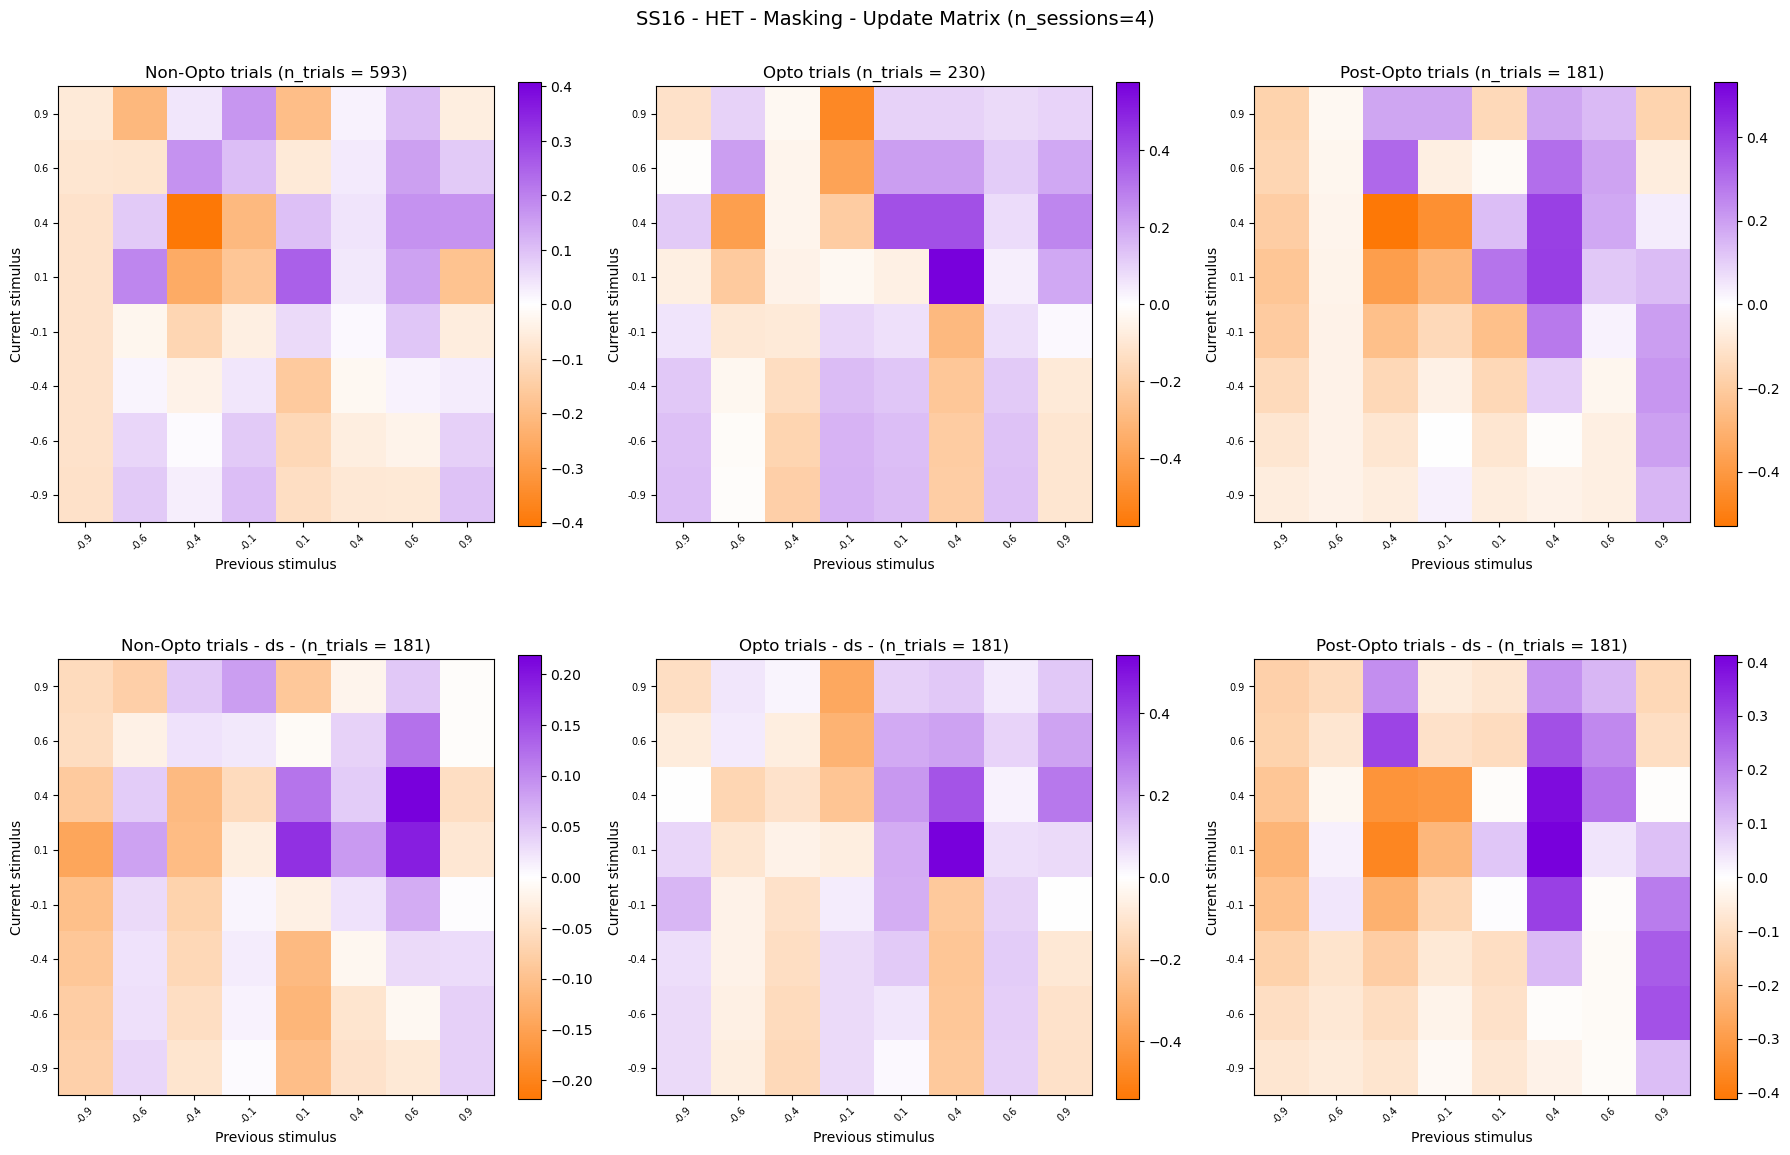

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Full
axs = axes[0]
plot_um(phase_non_opto_um_dist_sessionType, title=f"Non-Opto trials (n_trials = {phase_non_opto_um_dist_sessionType['n_trials']})", ax = axs[0])
plot_um(phase_opto_um_dist_sessionType, title=f"Opto trials (n_trials = {phase_opto_um_dist_sessionType['n_trials']})", ax = axs[1])
plot_um(phase_post_opto_um_dist_sessionType, title=f"Post-Opto trials (n_trials = {phase_post_opto_um_dist_sessionType['n_trials']})", ax = axs[2])

# Downsampled
axs = axes[1]
plot_um(phase_non_opto_ds_um_dist_sessionType, title=f"Non-Opto trials - ds - (n_trials = {phase_non_opto_ds_um_dist_sessionType['n_trials']})", ax = axs[0])
plot_um(phase_opto_ds_um_dist_sessionType, title=f"Opto trials - ds - (n_trials = {phase_opto_ds_um_dist_sessionType['n_trials']})", ax = axs[1])
plot_um(phase_post_opto_ds_um_dist_sessionType, title=f"Post-Opto trials - ds - (n_trials = {phase_post_opto_ds_um_dist_sessionType['n_trials']})", ax = axs[2])


fig.suptitle(f"{animal.animal_id} - {animal.genotype.upper()} - {phases_dist_sessionType['opto'][0].session_type.capitalize()} - Update Matrix (n_sessions={len(phases_dist_sessionType['opto'])})", fontsize=14)
plt.tight_layout()

##### Stats

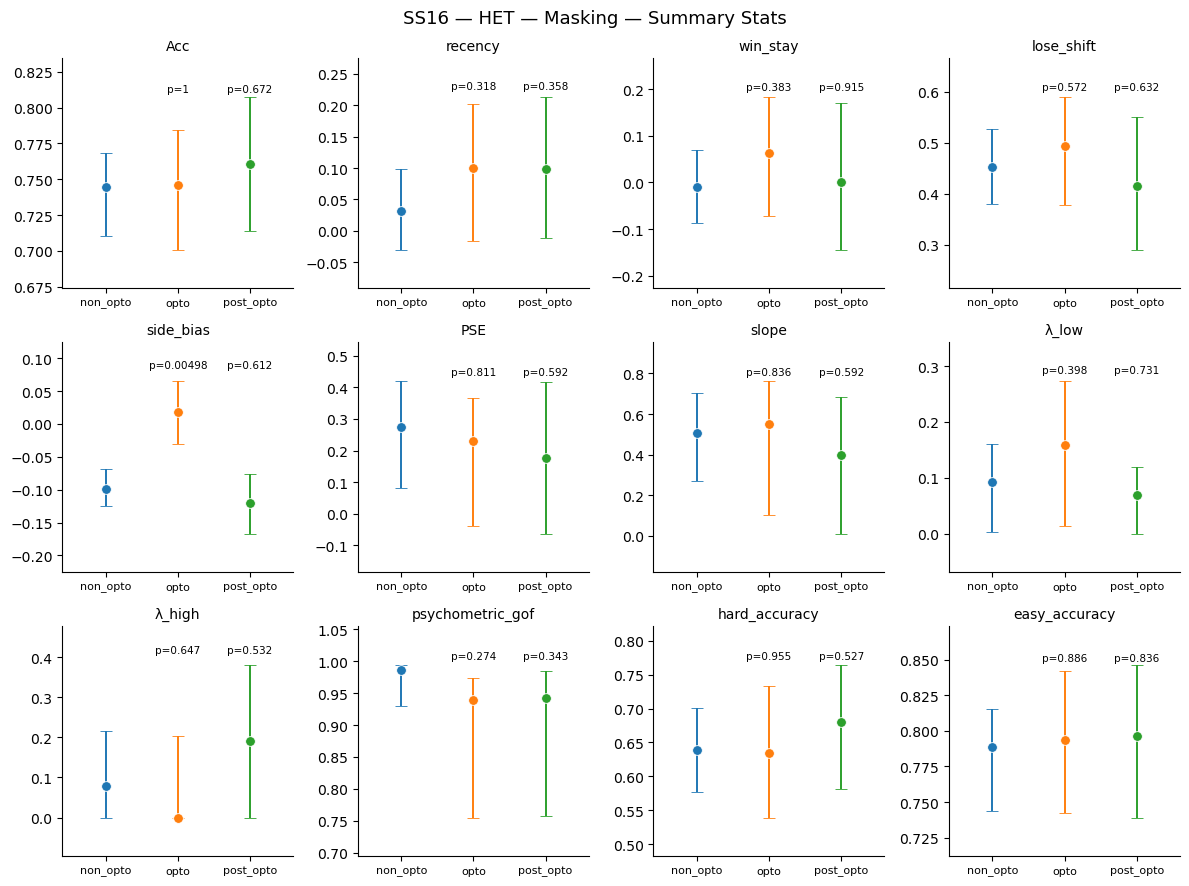

In [11]:
from behav_utils.plotting.comparison import plot_stat_comparison

fig, axes = plot_stat_comparison(stats_full_dist_sessionType, ncols=4,
    suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — {phases_dist_sessionType['opto'][0].session_type.capitalize()} — Summary Stats")


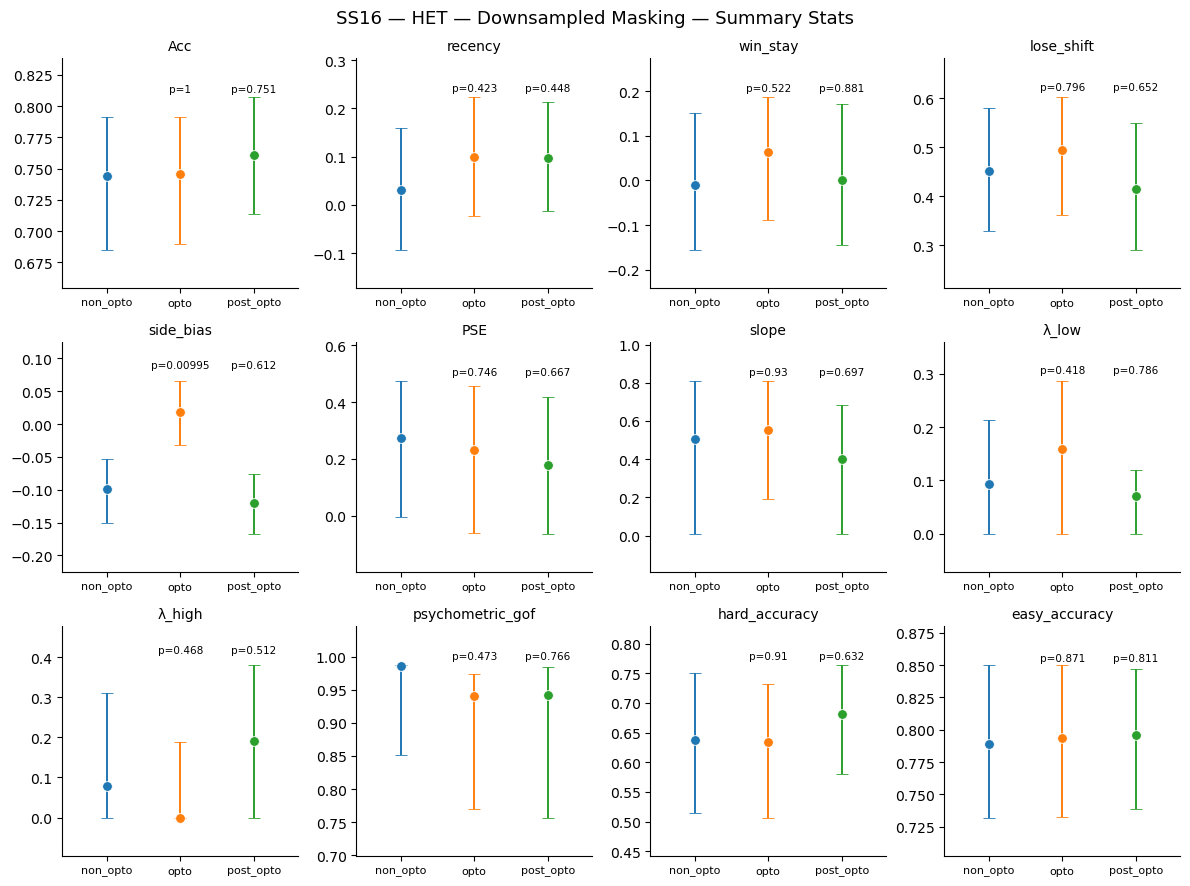

In [12]:
fig, axes = plot_stat_comparison(stats_ds_dist_sessionType, ncols=4,
    suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — Downsampled {phases_dist_sessionType['opto'][0].session_type.capitalize()} — Summary Stats")


### Phase Comparison

In [23]:
animal.session_table['session_type'].unique()

array(['regular', 'masking', 'opto', 'washout', 'alm_control_uni',
       'alm_control_bi'], dtype=object)

In [24]:
from behav_utils.analysis.comparison import compute_interaction

distribution = 'Uniform'
session_type = 'masking'
phase_unfiltered = select_sessions(animal, distribution=distribution, session_type=session_type)
phases_dist_sessionType_1 = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

distribution = 'Uniform'
session_type = 'opto'
phase_unfiltered = select_sessions(animal, distribution=distribution, session_type=session_type)
phases_dist_sessionType_2 = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

distribution = 'Uniform'
session_type = 'alm_control_uni'
phase_unfiltered = select_sessions(animal, distribution=distribution, session_type=session_type)
phases_dist_sessionType_3 = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

res_mask = compare_phases(phases_dist_sessionType_1, stats=stat_names, reference='non_opto')
res_opto = compare_phases(phases_dist_sessionType_2, stats=stat_names, reference='non_opto')
res_alm_control = compare_phases(phases_dist_sessionType_3, stats=stat_names, reference='non_opto')

inter_opto = compute_interaction(res_mask, res_opto, contrast='opto_vs_non_opto', label_a = 'masking', label_b = 'opto')
inter_alm_control = compute_interaction(res_mask, res_alm_control, contrast='opto_vs_non_opto', label_a = 'masking', label_b = 'alm_control')

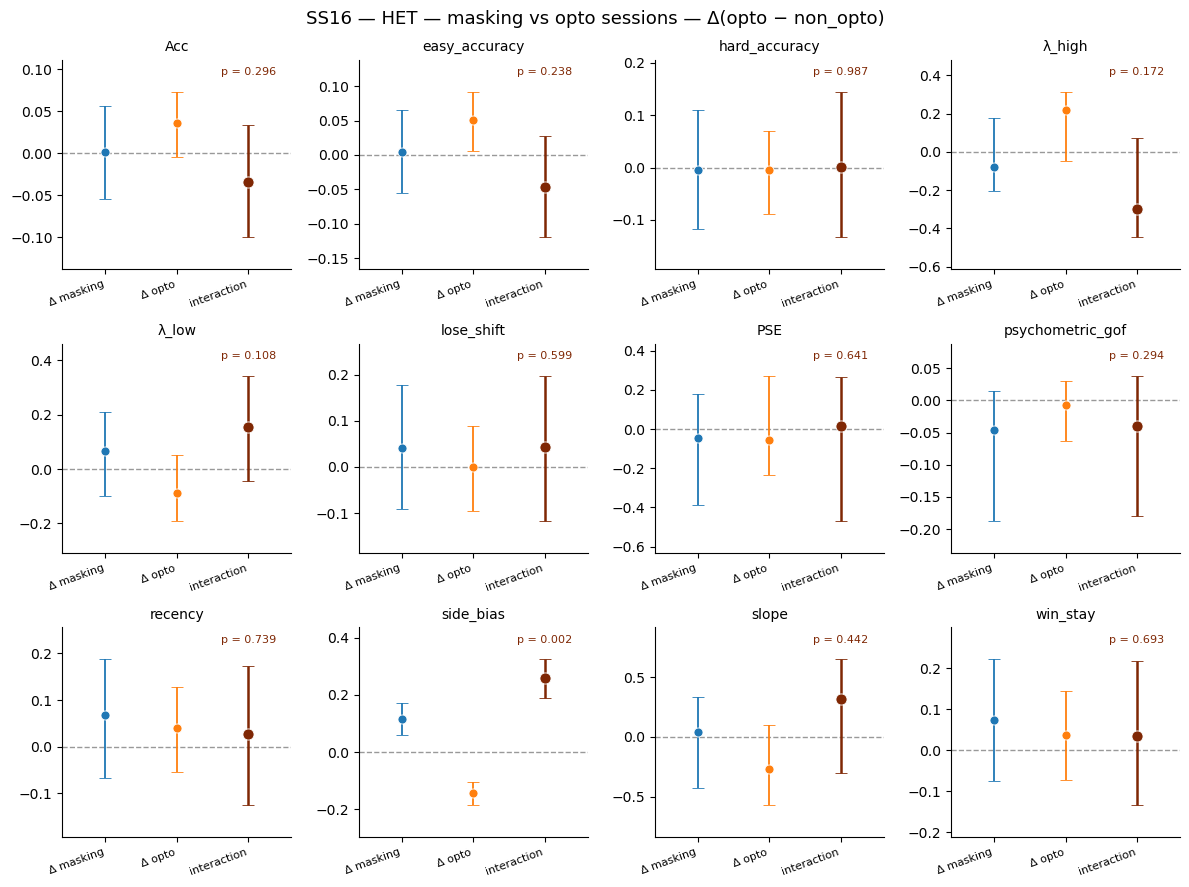

In [ ]:
from behav_utils.plotting.comparison import plot_interaction

fig, axes = plot_interaction(inter_opto, ncols=4,
    suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — masking vs opto sessions — Δ(opto − non_opto)")

ValueError: 'yerr' must not contain negative values

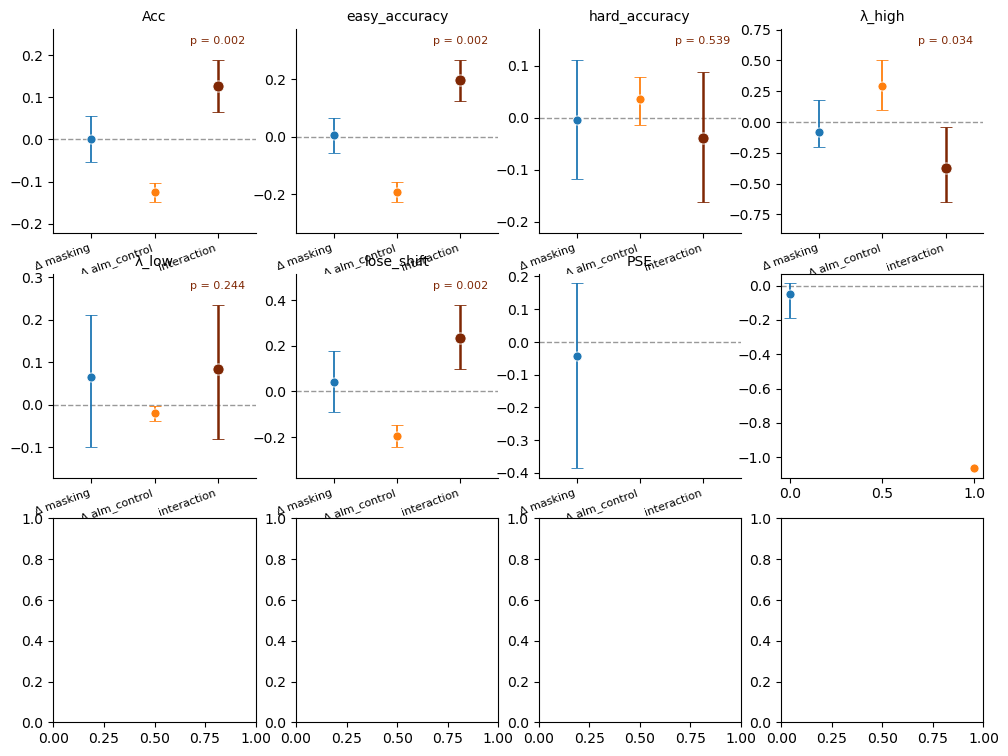

In [25]:
fig, axes = plot_interaction(inter_alm_control, ncols=4,
    suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — masking vs alm control sessions — Δ(opto − non_opto)")

In [ ]:
stat_names = ['accuracy', 'recency', 'win_stay', 'lose_shift', 'side_bias', 
              'psychometric', 'psychometric_gof',
              'hard_accuracy', 'easy_accuracy']

animal_id_list = ['SS14', 'SS15', 'SS16', 'SS17', 'SS18', 'SS20', 'SS21', 'SS22', 'SS23']
distribution_list = ['Uniform']
session_type_list = ['masking', 'opto', 'alm_control_uni']

for animal_id in animal_id_list:
	animal = experiment.get_animal(animal_id)
	print(f"Animal: {animal.animal_id} ({animal.genotype.upper()})")

	for distribution in distribution_list:
		for session_type in session_type_list:
			phase_unfiltered = select_sessions(animal, distribution=distribution, session_type=session_type)
			phases_dist_sessionType = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

			stats_full_dist_sessionType = compare_phases(phases_dist_sessionType, stats=stat_names, downsample = False, 
							n_permutations = 200, n_bootstrap = 200, 
							reference='non_opto')

			stats_ds_dist_sessionType = compare_phases(phases_dist_sessionType, stats=stat_names, downsample = True,
							n_permutations = 200, n_bootstrap = 200, reference = 'non_opto')


			phase_opto_um_dist_sessionType = compute_um(phases_dist_sessionType['opto'])
			phase_non_opto_um_dist_sessionType = compute_um(phases_dist_sessionType['non_opto'])
			phase_post_opto_um_dist_sessionType = compute_um(phases_dist_sessionType['post_opto'])


			n = calculate_min_n([phases_dist_sessionType['opto'], phases_dist_sessionType['non_opto'], phases_dist_sessionType['post_opto']], unit = 'pairs')
			phase_opto_ds_um_full_dist_sessionType = compute_ds_x(phases_dist_sessionType['opto'], 'um', n, n_repeats=100)   # 100 matched draws, aggregated
			phase_non_opto_ds_um_full_dist_sessionType = compute_ds_x(phases_dist_sessionType['non_opto'], 'um', n, n_repeats=100)
			phase_post_opto_ds_um_full_dist_sessionType = compute_ds_x(phases_dist_sessionType['post_opto'], 'um', n, n_repeats=100)
			phase_opto_ds_um_dist_sessionType = phase_opto_ds_um_full_dist_sessionType['aggregated']
			phase_non_opto_ds_um_dist_sessionType = phase_non_opto_ds_um_full_dist_sessionType['aggregated']
			phase_post_opto_ds_um_dist_sessionType = phase_post_opto_ds_um_full_dist_sessionType['aggregated']
   
			fig, axes = plt.subplots(1, 2, figsize=(12, 6))
			# Full
			plot_psychometric(stats_full_dist_sessionType['phases']['non_opto']['psychometric'], title=f"Opto vs Nonopto trials ", ax = axes[0], color = PALETTE[0], 
							label=f'Opto (n={stats_full_dist_sessionType["phases"]["non_opto"]["n_trials"]})')
			plot_psychometric(stats_full_dist_sessionType['phases']['opto']['psychometric'], title=f"Opto vs Nonopto trials", ax = axes[0], color = PALETTE[1], 
							label=f'Non-Opto (n={stats_full_dist_sessionType["phases"]["non_opto"]["n_trials"]})')
			plot_psychometric(stats_full_dist_sessionType['phases']['post_opto']['psychometric'], title=f"Opto vs Nonopto trials", ax = axes[0], color = PALETTE[2], 
							label=f'Post-Opto (n={stats_full_dist_sessionType["phases"]["post_opto"]["n_trials"]})')
			axes[0].legend()

			# Downsampled
			plot_psychometric(stats_ds_dist_sessionType['phases']['opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[0], 
							label=f'Opto (n={stats_ds_dist_sessionType["phases"]["opto"]["n_trials"]})')
			plot_psychometric(stats_ds_dist_sessionType['phases']['non_opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[1], 
							label=f'Non-Opto (n={stats_ds_dist_sessionType["phases"]["non_opto"]["n_trials"]})')
			plot_psychometric(stats_ds_dist_sessionType['phases']['post_opto']['psychometric'], title=f"Opto vs Nonopto trials (downsampled)", ax = axes[1], color = PALETTE[2], 
							label=f'Post-Opto (n={stats_ds_dist_sessionType["phases"]["post_opto"]["n_trials"]})')
			axes[1].legend()

			fig.suptitle(f"{animal.animal_id} - {animal.genotype.upper()} - {phases_dist_sessionType['non_opto'][0].session_type.capitalize()} Sessions - Psychometric Curves (n_sessions={stats_full_dist_sessionType['phases']['non_opto']['n_sessions']})", fontsize=14)
			plt.tight_layout()
			# fig.savefig(f"{animal.animal_id}_{distribution}_{session_type}_psychometric_curves.png", dpi=300)
   
			fig, axes = plt.subplots(2, 3, figsize=(18, 12))

			# Full
			axs = axes[0]
			plot_um(phase_non_opto_um_dist_sessionType, title=f"Non-Opto trials (n_trials = {phase_non_opto_um_dist_sessionType['n_trials']})", ax = axs[0])
			plot_um(phase_opto_um_dist_sessionType, title=f"Opto trials (n_trials = {phase_opto_um_dist_sessionType['n_trials']})", ax = axs[1])
			plot_um(phase_post_opto_um_dist_sessionType, title=f"Post-Opto trials (n_trials = {phase_post_opto_um_dist_sessionType['n_trials']})", ax = axs[2])

			# Downsampled
			axs = axes[1]
			plot_um(phase_non_opto_ds_um_dist_sessionType, title=f"Non-Opto trials - ds - (n_trials = {phase_non_opto_ds_um_dist_sessionType['n_trials']})", ax = axs[0])
			plot_um(phase_opto_ds_um_dist_sessionType, title=f"Opto trials - ds - (n_trials = {phase_opto_ds_um_dist_sessionType['n_trials']})", ax = axs[1])
			plot_um(phase_post_opto_ds_um_dist_sessionType, title=f"Post-Opto trials - ds - (n_trials = {phase_post_opto_ds_um_dist_sessionType['n_trials']})", ax = axs[2])


			fig.suptitle(f"{animal.animal_id} - {animal.genotype.upper()} - {phases_dist_sessionType['opto'][0].session_type.capitalize()} - Update Matrix (n_sessions={len(phases_dist_sessionType['opto'])})", fontsize=14)
			plt.tight_layout()
			# fig.savefig(f"{animal.animal_id}_{distribution}_{session_type}_update_matrix.png", dpi=300)
   
   
			fig, axes = plot_stat_comparison(stats_full_dist_sessionType, ncols=4,
				suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — {phases_dist_sessionType['opto'][0].session_type.capitalize()} — Summary Stats")
			# fig.savefig(f"{animal.animal_id}_{distribution}_{session_type}_summary_stats.png", dpi=300)

			fig, axes = plot_stat_comparison(stats_ds_dist_sessionType, ncols=4,
				suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — Downsampled {phases_dist_sessionType['opto'][0].session_type.capitalize()} — Summary Stats")
			# fig.savefig(f"{animal.animal_id}_{distribution}_{session_type}_summary_stats_downsampled.png", dpi=300)

	session_type = 'masking'
	phase_unfiltered = select_sessions(animal, distribution='Uniform', session_type=session_type)
	phases_dist_sessionType_1 = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

	session_type = 'opto'
	phase_unfiltered = select_sessions(animal, distribution='Uniform', session_type=session_type)
	phases_dist_sessionType_2 = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

	session_type = 'alm_control_uni'
	phase_unfiltered = select_sessions(animal, distribution='Uniform', session_type=session_type)
	phases_dist_sessionType_3 = {tt: filter_trials(phase_unfiltered, trial_type=tt) for tt in ['non_opto', 'opto', 'post_opto']}

	res_mask = compare_phases(phases_dist_sessionType_1, stats=stat_names, reference='non_opto')
	res_opto = compare_phases(phases_dist_sessionType_2, stats=stat_names, reference='non_opto')
	res_alm_control = compare_phases(phases_dist_sessionType_3, stats=stat_names, reference='non_opto')

	inter_opto = compute_interaction(res_mask, res_opto, contrast='opto_vs_non_opto', label_a = 'masking', label_b = 'opto')
	inter_alm_control = compute_interaction(res_mask, res_alm_control, contrast='opto_vs_non_opto', label_a = 'masking', label_b = 'alm_control')
	
	fig, axes = plot_interaction(inter_opto, ncols=4,
		suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — masking vs opto sessions — Δ(opto − non_opto)")
	# fig.savefig(f"{animal.animal_id}_{distribution}_{session_type}_interaction_opto.png", dpi=300)
 
	fig, axes = plot_interaction(inter_alm_control, ncols=4,
		suptitle=f"{animal.animal_id} — {animal.genotype.upper()} — masking vs alm control sessions — Δ(opto − non_opto)")
	# fig.savefig(f"{animal.animal_id}_{distribution}_{session_type}_interaction_alm_control.png", dpi=300)
				

## Per Genotype